In [2]:
import pandas as pd
import sqlite3
import datetime
from os import path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from functools import reduce

In [3]:

#--------Directories ---------------------------------------
## Project directory
project_dir = path.dirname(path.dirname(path.abspath('')))

## Location of database files
db_dir = path.join(project_dir,"files", "data", "lfs", "UWB")

## Location for Graphs
graph_dir = path.join(project_dir, "files", "data", "lfs","UWB",  "graphs")

## Location for Graphs
metadata_dir = path.join(project_dir, "files", "data", "lfs","UWB", "metadata")

## Location for data_tables
data_tables_dir = path.join(project_dir, "files", "data", "lfs","UWB", "data_tables")

In [4]:
def generate_lineplot(df, select_date_start=None, select_date_end=None, component=None,
                      scope=None, save_fig=True, graphs_dir=graph_dir,
                      stations_meta=None, components_meta=None):

    # --- Date range ---
    start = select_date_start if select_date_start else str(df['date_start'].iloc[0])
    end   = select_date_end   if select_date_end   else str(df['date_start'].iloc[-1])

    df_plt = df.query(f'date_start >= "{start}" and date_start < "{end}"').copy()

    # --- Metadata lookups ---
    # Component info
    comp_name, comp_symbol, comp_unit = "Unknown", "", ""
    if components_meta is not None and component is not None:
        row = components_meta[components_meta['component_id'] == component]
        if not row.empty:
            comp_name   = row['component_name'].values[0]
            comp_symbol = row['component_symbol'].values[0]
            comp_unit   = row['component_unit'].values[0]

    # Station label map: station_id → "CODE – Name"
    label_map = {}
    if stations_meta is not None:
        for sid in df_plt['station_id'].unique():
            row = stations_meta[stations_meta['station_id'] == sid]
            if not row.empty:
                code = row['station_code'].values[0]
                name = row['station_name'].values[0]
                label_map[sid] = f"{code} – {name}"
            else:
                label_map[sid] = str(sid)

    df_plt['station_label'] = df_plt['station_id'].map(label_map).fillna(df_plt['station_id'].astype(str))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(40, 10))

    sns.lineplot(data=df_plt, x="date_start", y="value",
                 hue="station_label", ax=ax, linewidth=1.2)

    # Title
    date_range_str = f"{start[:10]}  →  {end[:10]}"
    ax.set_title(
        f"{comp_name} ({comp_symbol})  |  {date_range_str}",
        fontsize=18, fontweight='bold', pad=16
    )

    # Axis labels
    ax.set_xlabel("Datum", fontsize=13)
    ax.set_ylabel(f"{comp_symbol}  [{comp_unit}]", fontsize=13)

    # Legend
    ax.legend(
        title="Messstation",
        title_fontsize=12,
        fontsize=11,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=True
    )

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%Y-%m-%d')
    )
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    # --- Save ---
    if save_fig:
        plt_name = f'UWB_{comp_symbol}_{start[:10]}--{end[:10]}.pdf'
        file_path = path.join(graph_dir, plt_name)
        fig.savefig(file_path, bbox_inches='tight')

    plt.show()

In [5]:
def heatmap_missing_values(df, save_fig = True, graphs_dir=graph_dir, component = None):
    # Create a boolean mask for null values
    null_mask = df.isna()

    # Create the heatmap
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(null_mask, 
                cbar_kws={'label': 'Missing Data'},
                cmap='viridis', ax=ax)
    plt.title('Missing Values Heatmap', fontsize=16, pad=20)
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Rows', fontsize=12)
    plt.tight_layout()

    # --- Save ---
    if save_fig:
        if component == None:
            plt_name = f'Missing_values_heatmap.png'
        else:
            plt_name = f'Missing_values_heatmap_comp-{component}.png'
        file_path = path.join(graph_dir, plt_name)
        fig.savefig(file_path, bbox_inches='tight')

        
    plt.show()

In [6]:
def filter_db_files(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db"
    ) -> list:
    if station_id == None:
        station_id ="*"

    if component == None:
        component = "*"

    if scope == None:
        scope = "*"

    mask = f'station_{station_id}*_comp_{component}*_scope_{scope}*{file_type}'
    files = glob.glob(path.join(db_dir, mask))
    files_filterd = []
    for file in files:
        if path.getsize(file) >= min_filesize:
            files_filterd.append(file)
    return files_filterd

In [7]:
def merge_dfs_by_station(df):
    '''
    merges all dfs of
    '''
    ## Return error if components don't have the same scope
    unique_scopes = df["scope_id"].unique()
    if len(unique_scopes)>1:
        print("Error, dataframes contain more than one scope. Scopes: ", unique_scopes)
        return -1
    
    unique_components = df["component_id"].unique()
    frames =[]
    for component in unique_components:
        df_c = df[df["component_id"] ==component]
        df_c.rename(columns={'value':component}, inplace=True)
        df_c.drop(columns=['component_id', 'station_id', 'scope_id', 'date_end'], inplace=True)
        frames.append(df_c)
        print(df_c.head())

    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on='date_start', how='left'), 
        frames
    )

    merged_df =merged_df.set_index(keys='date_start')
    return merged_df

In [8]:
def load_dbs(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db",
        project_dir: str = 'files/data/lfs/UWB'
    ) -> list:
    dfs = []
    files = filter_db_files(station_id, component, scope, min_filesize, file_type)
    for file in files:
        conn = sqlite3.connect(file)
        df = pd.read_sql_query("SELECT * FROM measurements", conn)
        dfs.append(df)
    df = pd.concat(dfs,ignore_index=True)

    # 1. Identify which rows have the 24:00:00 problem
    mask = df["date_end"].str.contains("24:00:00")

    # 2. Replace 24:00:00 with 00:00:00 so pandas can parse it
    df["date_end"] = df["date_end"].str.replace("24:00:00", "00:00:00")

    # 3. Convert to datetime
    df["date_end"] = pd.to_datetime(df["date_end"])

    # 4. Add exactly 1 day to the rows that originally had 24:00:00
    df.loc[mask, "date_end"] += pd.Timedelta(days=1)
    df["date_start"] = pd.to_datetime(df["date_start"])
    df["date_end"] = pd.to_datetime(df["date_end"])
    df["station_id"] = df["station_id"].astype(str)
    df = df.drop("index_value", axis=1)

    return df

In [9]:
#------ Drop stations withouth full range of dates

def drop_incomplete_stations(df, select_date_start='2018-01-01', select_date_end='2025-12-31 23:00:00'):

    '''
    Drop all measurement stations from the dataset that don't 
    cover measurements the specified range 
    '''
    # stations whose minimum start‑date is after 2018‑01‑01
    min_dates = df.groupby('station_id')['date_start'].min()
    max_dates = df.groupby('station_id')['date_start'].max()

    min_index =list(min_dates[min_dates > select_date_start].index)
    max_index =list(max_dates[max_dates < select_date_end].index)

    drop_index = min_index+ max_index

    # keep only rows whose station_id is **not** in the drop_index list
    df = df[~df["station_id"].isin(drop_index)]
    print("Stations dropped: ", drop_index)

    return df

In [10]:
df_all_stations = load_dbs('*', component="*", scope="2")
print(df_all_stations["station_id"].unique())

<StringArray>
[  '835',   '840',   '844',   '784',   '857', '10348',   '791',   '826',
   '846',   '802', '10466',   '855']
Length: 12, dtype: str


In [11]:
df_all_stations = drop_incomplete_stations(df_all_stations)
print(df_all_stations["station_id"].unique())


Stations dropped:  ['10348', '10466']
<StringArray>
['835', '840', '844', '784', '857', '791', '826', '846', '802', '855']
Length: 10, dtype: str


In [1]:
station_data_available = pd.DataFrame([], columns=["station_id", 'components'])

NameError: name 'pd' is not defined

In [31]:
stations_list = df_all_stations["station_id"].unique()

In [ ]:
stations_list = df_all_stations["station_id"].unique()



for station in stations_list:
    df_stations = df_all_stations.query("station_id == @station")
    df_stations_merged = merge_dfs_by_station(df_stations)

    dt_start = str(df_stations_merged.index[0])[:10]
    dt_end = str(df_stations_merged.index[-1])[:10]
    filen_ame = f"Station_{station}_{dt_start}--{dt_end}.csv"
    file_path = path.join(data_tables_dir, filen_ame)
    df_stations_merged.to_csv(file_path)

           date_start     5
0 2018-01-01 00:00:00  36.0
1 2018-01-01 01:00:00  15.0
2 2018-01-01 02:00:00   4.0
3 2018-01-01 03:00:00   8.0
4 2018-01-01 04:00:00   9.0
                date_start      1
990600 2018-01-01 00:00:00  129.0
990601 2018-01-01 01:00:00  263.0
990602 2018-01-01 02:00:00   29.0
990603 2018-01-01 03:00:00   17.0
990604 2018-01-01 04:00:00   11.0
                 date_start    4
1288656 2018-01-01 00:00:00  6.0
1288657 2018-01-01 01:00:00  6.0
1288658 2018-01-01 02:00:00  3.0
1288659 2018-01-01 03:00:00  3.0
1288660 2018-01-01 04:00:00  6.0
                 date_start   3
1525344 2025-12-01 00:00:00 NaN
1525345 2025-12-01 01:00:00 NaN
1525346 2025-12-01 02:00:00 NaN
1525347 2025-12-01 03:00:00 NaN
1525348 2025-12-01 04:00:00 NaN
               date_start      1
70128 2024-01-01 00:00:00  157.0
70129 2024-01-01 01:00:00  122.0
70130 2024-01-01 02:00:00   43.0
70131 2024-01-01 03:00:00   18.0
70132 2024-01-01 04:00:00   18.0
                date_start     5
753912 

In [19]:
## Load the metadata
stations_meta    = pd.read_csv(path.join(metadata_dir,"UWB_stations_metadata.csv"))
stations_meta['station_id'] = stations_meta['station_id'].astype(str)
components_meta  = pd.read_csv(path.join(metadata_dir,"UWB_components_metadata.csv"))

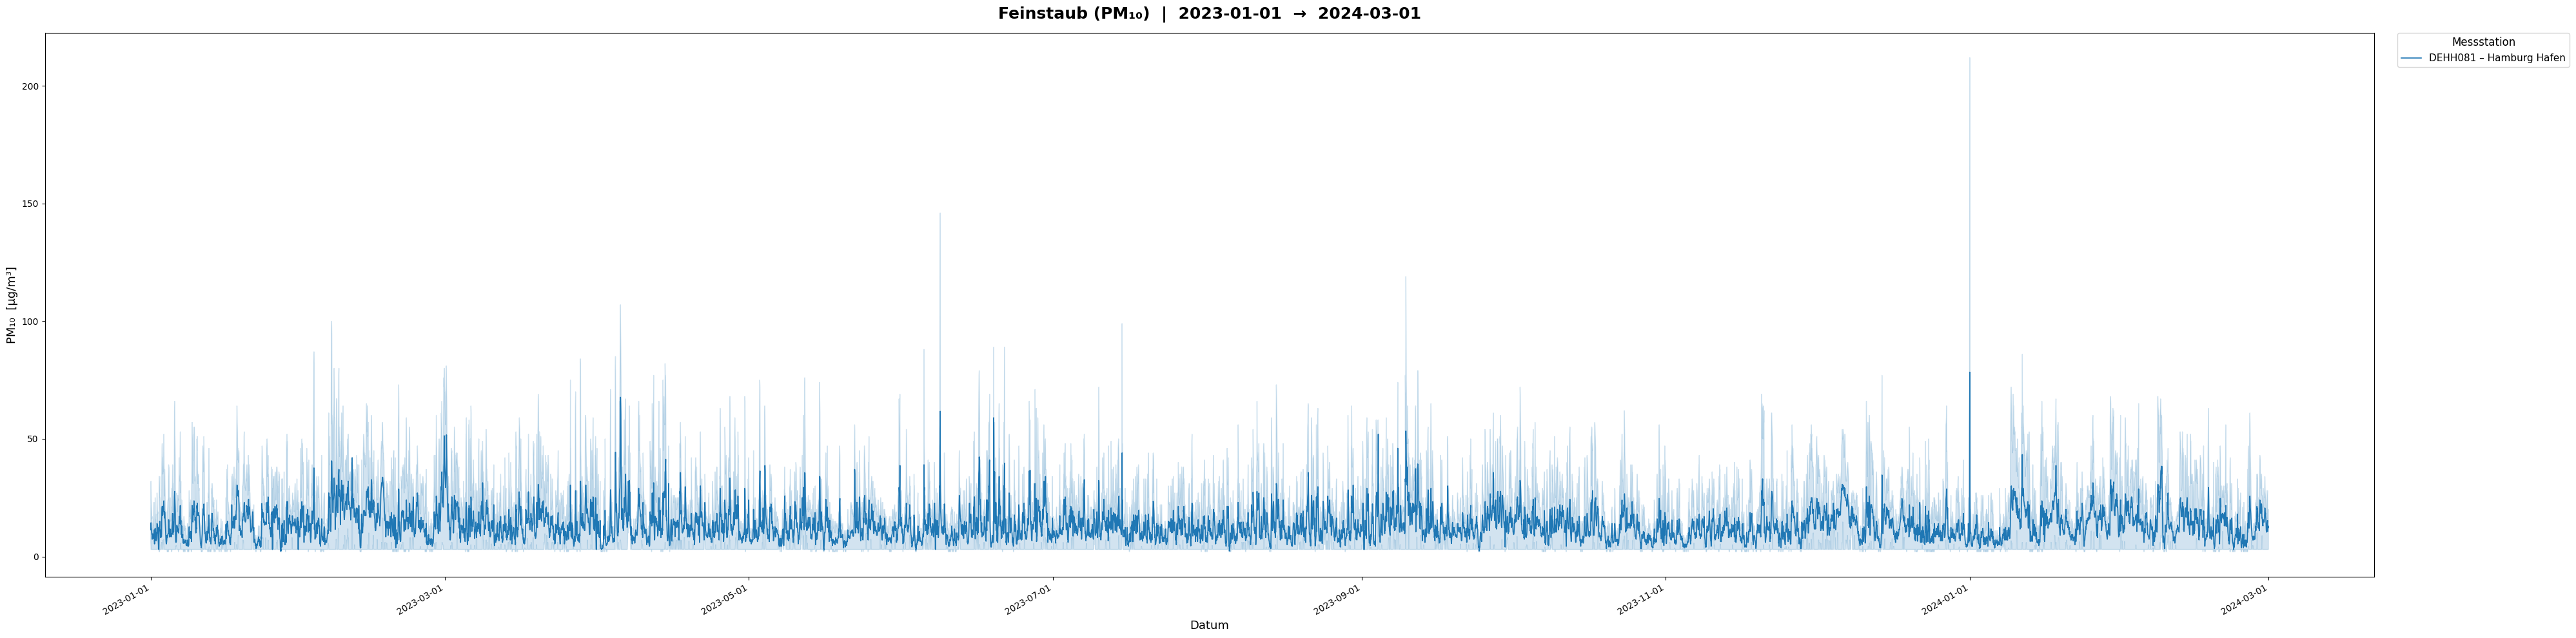

In [ ]:

generate_lineplot(
    df,
    select_date_start="2018",
    select_date_end="2024-03-01",
    component=1,                      # 1 = PM10 / Feinstaub
    stations_meta=stations_meta,
    components_meta=components_meta,
)

In [20]:
components_meta.head()

,component_id,component_code,component_symbol,component_unit,component_name
0,1,PM10,PM₁₀,µg/m³,Feinstaub
1,2,CO,CO,mg/m³,Kohlenmonoxid
2,3,O3,O₃,µg/m³,Ozon
3,4,SO2,SO₂,µg/m³,Schwefeldioxid
4,5,NO2,NO₂,µg/m³,Stickstoffdioxid


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_start    210384 non-null  datetime64[us]
 1   date_end      210384 non-null  datetime64[us]
 2   station_id    210384 non-null  str           
 3   component_id  210384 non-null  int64         
 4   scope_id      210384 non-null  int64         
 5   value         207280 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 9.6 MB


In [26]:
# Filter for stations in Hamburg
stations_meta_ham = stations_meta[stations_meta["network_name"]=="Hamburg"]
stations_meta_ham.set_index('station_id',inplace=True)

In [27]:
stations_meta_ham.loc['857']

station_code                        DEHH081
station_name                  Hamburg Hafen
station_city                        Hamburg
station_synonym                         NaN
station_active_from              2015-09-29
station_active_to                       NaN
station_longitude                    9.9816
station_latitude                    53.5292
network_id                                6
station_setting_id                        1
station_type_id                           1
network_code                             HH
network_name                        Hamburg
station_setting_name             urban area
station_setting_short_name            urban
station_type_name                background
station_street                    Worthdamm
station_street_nr                        49
station_zip_code                      20457
Name: 857, dtype: object

In [28]:
components  = [1, 2, 3, 4, 5]

In [29]:
frames = []
for component in components:
    df = load_dbs('*', component=str(component), scope='*')
    frames.append(df)


In [30]:
df_hafen = pd.concat(frames)

In [31]:
df_hafen["station_id"].unique()

<StringArray>
[  '840',   '844',   '791',   '846',   '835',   '784',   '857', '10348',
   '802',   '855',   '826', '10466']
Length: 12, dtype: str

In [32]:
df_hafen.head()

,date_start,date_end,station_id,component_id,scope_id,value
0,2024-01-01 00:00:00,2024-01-01 01:00:00,840,1,6,NaN
1,2024-01-01 01:00:00,2024-01-01 02:00:00,840,1,6,NaN
2,2024-01-01 02:00:00,2024-01-01 03:00:00,840,1,6,NaN
3,2024-01-01 03:00:00,2024-01-01 04:00:00,840,1,6,NaN
4,2024-01-01 04:00:00,2024-01-01 05:00:00,840,1,6,NaN


In [33]:
df_hafen.tail()

,date_start,date_end,station_id,component_id,scope_id,value
736363,2025-12-31 19:00:00,2025-12-31 20:00:00,846,5,2,24.0
736364,2025-12-31 20:00:00,2025-12-31 21:00:00,846,5,2,21.0
736365,2025-12-31 21:00:00,2025-12-31 22:00:00,846,5,2,24.0
736366,2025-12-31 22:00:00,2025-12-31 23:00:00,846,5,2,15.0
736367,2025-12-31 23:00:00,2026-01-01 00:00:00,846,5,2,9.0


In [34]:
df_hafen.groupby('station_id')['date_start'].min()

station_id
10348   2024-01-01
10466   2024-01-01
784     2018-01-01
791     2018-01-01
802     2018-01-01
826     2018-01-01
835     2018-01-01
840     2018-01-01
844     2018-01-01
846     2018-01-01
855     2018-01-01
857     2018-01-01
Name: date_start, dtype: datetime64[us]

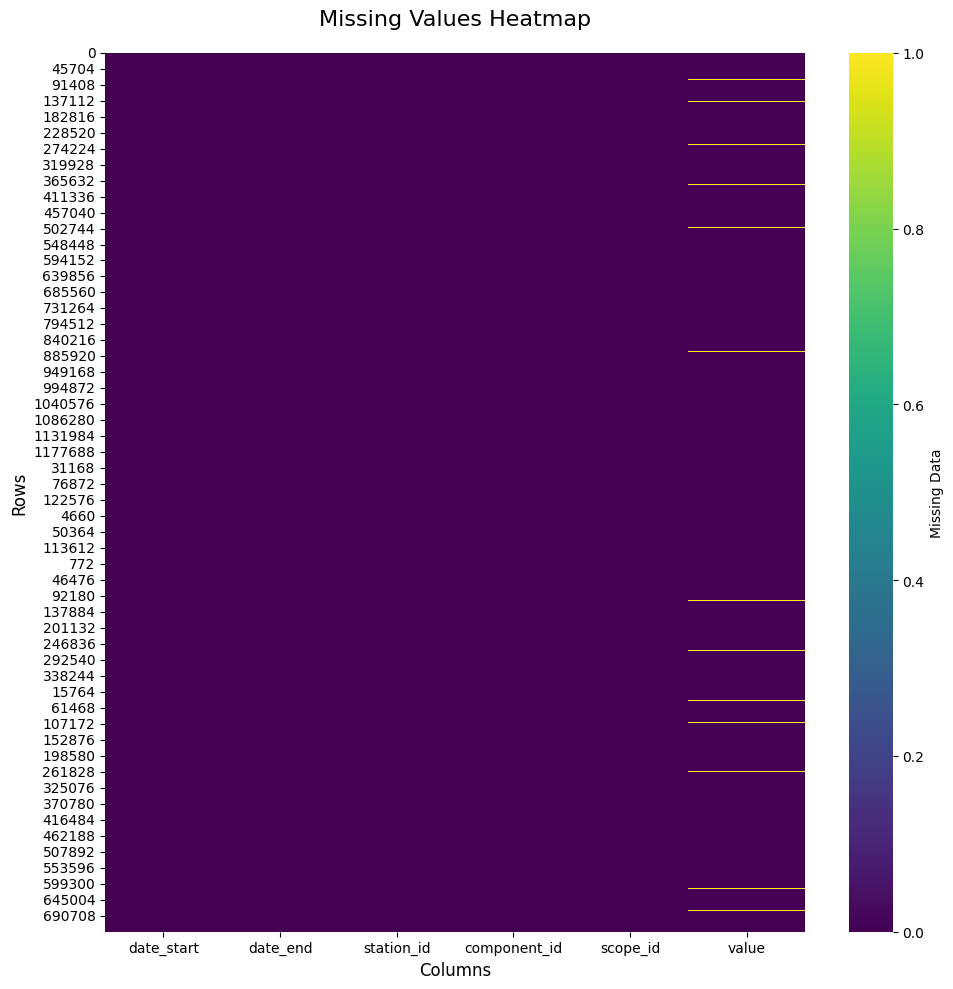

In [36]:
heatmap_missing_values(df_hafen, save_fig= True)